# Basal melt parameterisation analysis
[Finucane and Stewart (2024)](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024GL108196) present a parameterisation for basal melt of ice shelves based on bathymetric and hydrographic data. Let's see how much those estimates change with the different bathymetry products.

This notebook pretty much just implements the code presented in Garret's [repo](https://github.com/garrettdreyfus/geostrophic_basal_melt?tab=readme-ov-file).

In [1]:
import xarray as xr
import datetime

from scipy.ndimage import label 
import numpy as np
from tqdm import tqdm
import gsw,xarray, pyproj
import matplotlib.pyplot as plt
import numpy as np
import pickle
import matplotlib.colors as colors
import glob
from pathlib import Path


In [2]:
import dask.distributed as dask

client = dask.Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43225,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43183,Total threads: 1
Dashboard: /proxy/37637/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:33567,


In [3]:
import os
os.chdir('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
                'antarctic-bathymetry-project/geostrophic_basal_melt')

In [4]:
# import all the bits of code from basal melt repo
import bathtub as bt
import HUB
import woa
import paperfigures as pf
import cdw

In [5]:
#These flags just make it easy to turn off and steps of the analysis 
writeBedMach = True
writeShelfNumbers = True
writeHUB = True
writePolygons = True
writeGL = True
createWOA = True
createGISS = True
createClosestShelfPoints = True
createQuants = True
createSlopes = True

In [6]:
##################################################
#Create Polygon objects from MEASURES files
##################################################

if writePolygons:
    bt.save_polygons();

with open("data/shelfpolygons.pickle","rb") as f:
    shelf_polygons = pickle.load(f);

In [7]:
# shelf_polygons.keys()


In [8]:
def open_topog_file(short_name, data_dir = '/g/data/jk72/ed7737/access-om3/inputs/4km-PanAntarctic/bathy_products/'):
    """Quick and dirty function for opening the MOM6 topog files."""
    
    topog = xr.open_dataset(data_dir + short_name + '/topog.nc', chunks='auto')
    
    return topog

def write_topog_file(topog, short_name, data_dir = '/g/data/jk72/ed7737/access-om3/inputs/4km-PanAntarctic/bathy_products/'):
    """Quick and dirty function for opening the MOM6 topog files."""
    
    topog.to_netcdf(data_dir + short_name + '/topog_with_HUB.nc')
    
    return

def generateHUBs(depth,ice,resolution=5):
    #We don't care about the structure of the bathymetry off the shelf break for now
    # so we'll call the off shelf water the part that's greater than 2000 meters deep
    # and just set it to 2000 meters
    depth[depth<-2000] = -2000

    
    ## Grab a single point in the open ocean. We just made all the open ocean one depth so it is connected 
    openoceancoord = np.where(depth==-2000)
    openoceancoord = (openoceancoord[0][-1],openoceancoord[1][-1])

    ## Create the slices we'd like to search from -2000 to 0 using `resolution` provided in function call
    slices = - np.asarray(range(0,2000,resolution)[::-1])
    ## A matrix output we will fill with nans as we go.
    HUB = np.full_like(depth,np.nan)
    for iso_z in tqdm(slices):
        ### A mask that shows all points below our search depth that arent land or grounded ice.
        below = np.logical_and((depth<=iso_z),ice!=1)
        ### Use the image library label function to label connected regions.
        regions, _ = label(below)
        ### If any region is connected to open ocean at this depth and it hasn't been assigned a GLIB before (all ocean points are connected at z=0)
        ### then set it's glib to iso_z -20. The minus 20 is there because we are looking for the depth at which its not connected
        HUB[np.logical_and(regions==regions[openoceancoord],np.isnan(HUB))] = iso_z-resolution
    return HUB

In [9]:
topog_names = ['GEBCO24', 'GEBCO25', 'MEAN', 'DTU_DKL',
               'DTU_DNN', 'NCU_DNN', 'NRL_CNN', 'SRTM15_V2_7']

data_dir = '/g/data/jk72/ed7737/access-om3/inputs/4km-PanAntarctic/bathy_products/'

for name in topog_names:
    topog = open_topog_file(name)

    # Original code had icemask==0 in the ice regions, which hurt my brain, so I flipped it.
    icemask = xr.where(topog.depth>=10, 0, 1)
    icemask = icemask.where(topog.geolat_t<=-60, 0)
    icemask = icemask.values

    bedvalues = -topog.depth.values

    print("Calculating Hub for {0}".format(name))
    topog_hub = generateHUBs(bedvalues,icemask)
    
    topog['HUB'] = (('ny', 'nx'), topog_hub)

    today = datetime.datetime.today().strftime("%Y-%m-%d %H:%M")
    topog.attrs['history'] +='\n added highest unconnected isobath {0}'.format(today)
    
    topog.to_netcdf(data_dir + name + '/topog_with_HUB.nc')
    


Calculating Hub for GEBCO24


100%|██████████| 400/400 [00:19<00:00, 20.86it/s]


Calculating Hub for GEBCO25


100%|██████████| 400/400 [00:20<00:00, 19.97it/s]


Calculating Hub for MEAN


...

100%|██████████| 400/400 [00:18<00:00, 21.32it/s]


Calculating Hub for NRL_CNN


100%|██████████| 400/400 [00:18<00:00, 21.37it/s]


Calculating Hub for SRTM15_V2_7


100%|██████████| 400/400 [00:19<00:00, 20.94it/s]


In [10]:
files = sorted(glob.glob('/g/data/jk72/ed7737/access-om3/inputs/'+
                                    '4km-PanAntarctic/bathy_products/*/topog_with_HUB.nc'))

# get a coordinate for the new dimension
bathy_product=[]
for file in files:
    path_with_file = Path(file)
    bathy_product.append(path_with_file.parent.name)
    
topogs_with_hub = xr.open_mfdataset(files, chunks='auto',
                                    combine='nested', concat_dim='bathy_product',
                                   )

topogs_with_hub['bathy_product'] = sorted(bathy_product)

In [11]:



topogs_with_hub

<xarray.Dataset> Size: 997MB
Dimensions:            (bathy_product: 8, ny: 1442, nx: 4320)
Coordinates:
  * bathy_product      (bathy_product) <U11 352B 'DTU_DKL' ... 'SRTM15_V2_7'
Dimensions without coordinates: ny, nx
Data variables:
    depth              (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    sea_area_fraction  (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    geolon_t           (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    geolat_t           (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    HUB                (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
Attributes:
    original_file:  topog_new_fillfraction_edited_deseas.nc
    input_file:     /g/data/vk83/prerelease/configurations/inputs/access-om3/...
    history:        Fri Jan 16 15:08:27 2026 +1100: topogtools min_max_depth ...

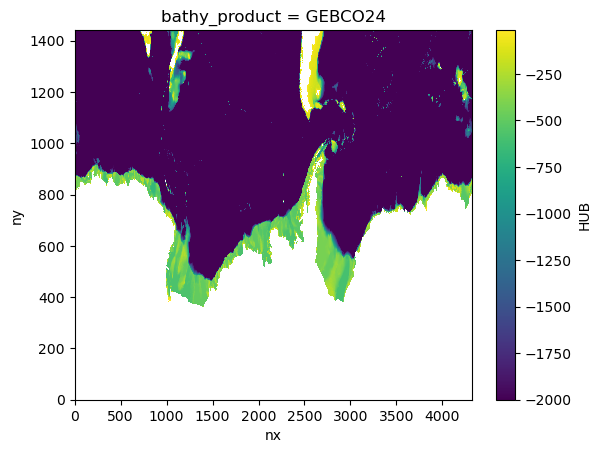

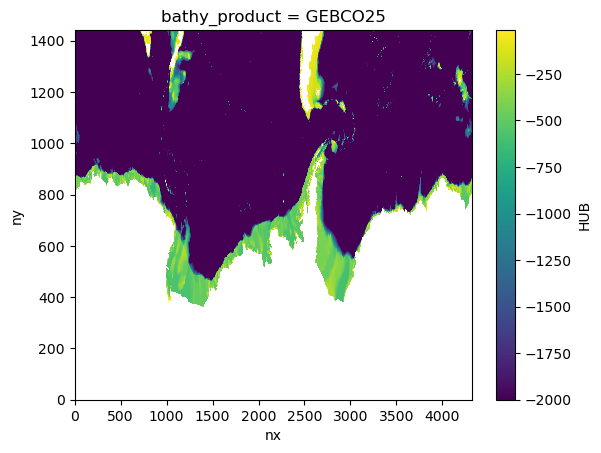

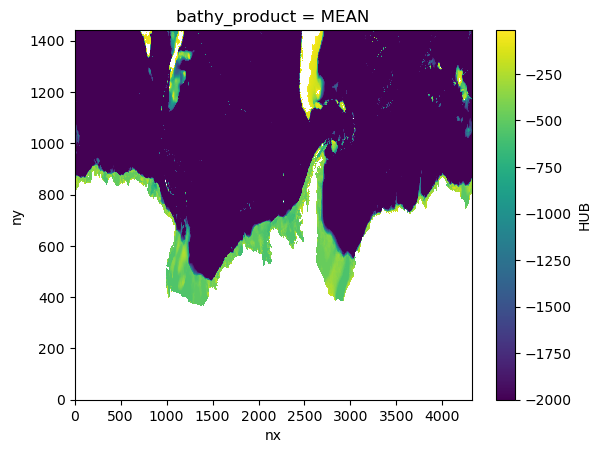

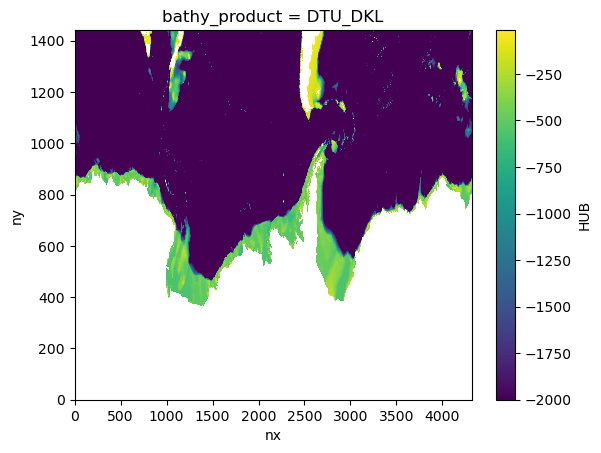

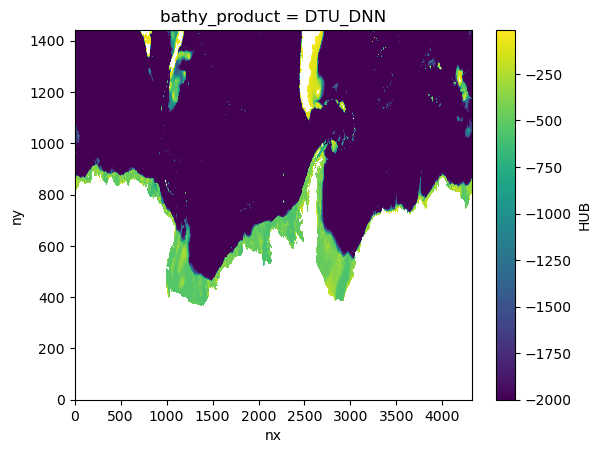

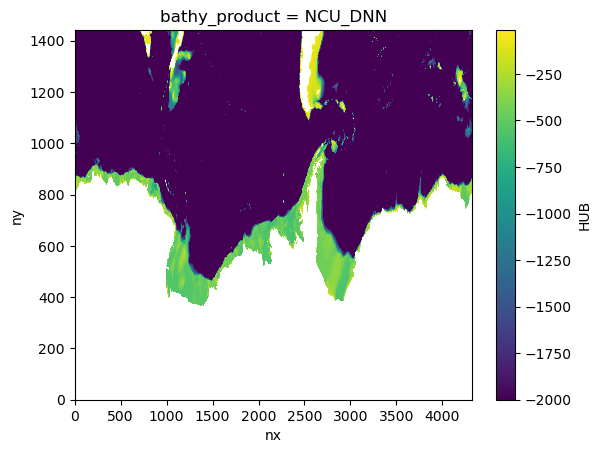

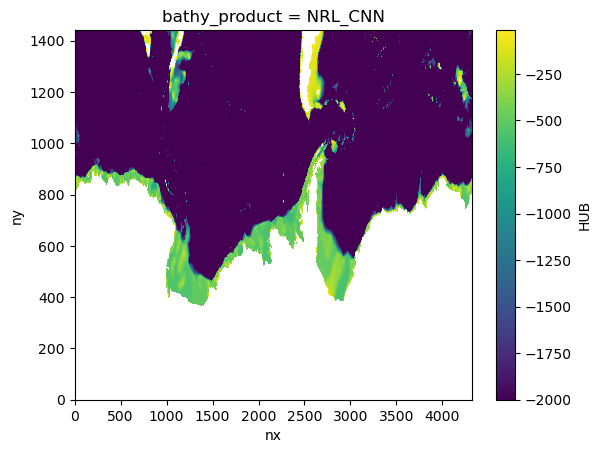

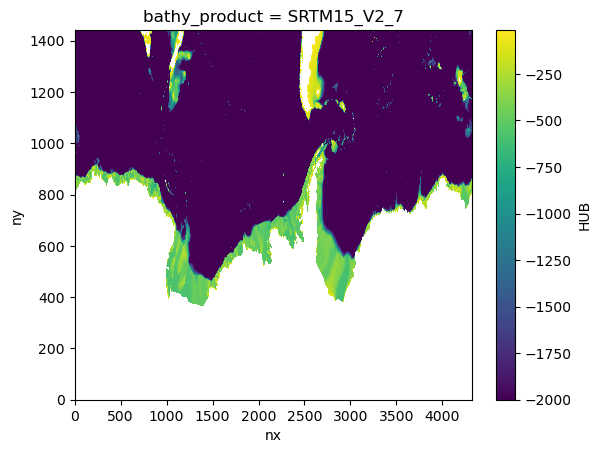

In [12]:
for name in topog_names:
    plt.figure()
    topogs_with_hub['HUB'].sel(bathy_product=name).plot()

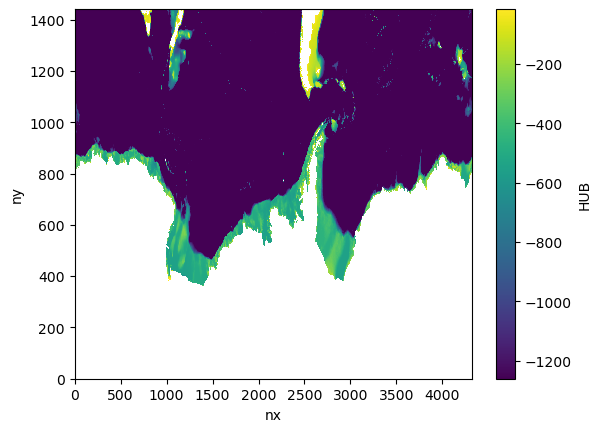

In [38]:
topogs_with_hub['HUB'].mean(dim='bathy_product').plot()

In [22]:
ML_topogs_HUB_std = topogs_with_hub['HUB'].sel(bathy_product=['DTU_DKL','DTU_DNN',
            'NCU_DNN', 'NRL_CNN']).std(dim='bathy_product')

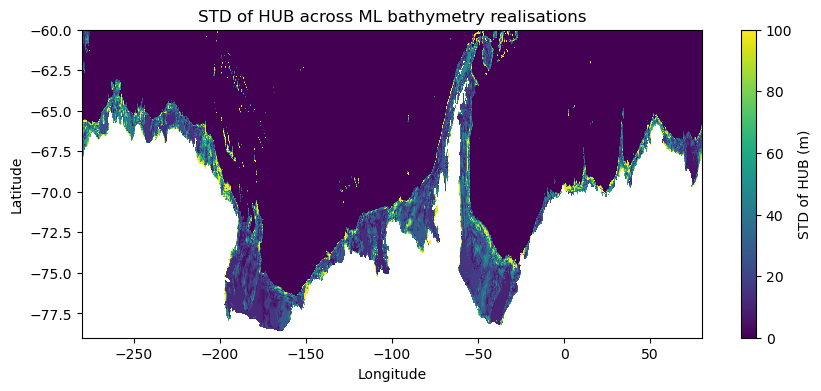

In [44]:
plt.figure(figsize=(10,4))
plt.pcolormesh(topogs_with_hub.sel(bathy_product='MEAN')['geolon_t'],
               topogs_with_hub.sel(bathy_product='MEAN')['geolat_t'],
               ML_topogs_HUB_std, vmin=0, vmax=100)

plt.ylim(-79, -60)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

CB = plt.colorbar()
CB.set_label('STD of HUB (m)')
plt.title('STD of HUB across ML bathymetry realisations')
plt.savefig('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
            'antarctic-bathymetry-project/analysis/ML_bathymetries_std_HUB.png',
            dpi=200, bbox_inches='tight')

In [47]:


all_topogs_HUB_std = topogs_with_hub['HUB'].sel(bathy_product=['GEBCO24', 'GEBCO25',
                'DTU_DKL', 'DTU_DNN', 'NCU_DNN', 'NRL_CNN',
                'SRTM15_V2_7']).std(dim='bathy_product')

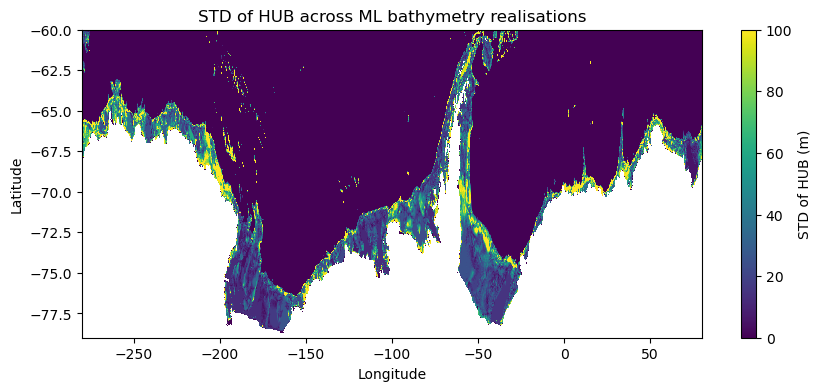

In [48]:
plt.figure(figsize=(10,4))
plt.pcolormesh(topogs_with_hub.sel(bathy_product='MEAN')['geolon_t'],
               topogs_with_hub.sel(bathy_product='MEAN')['geolat_t'],
               all_topogs_HUB_std, vmin=0, vmax=100)

plt.ylim(-79, -60)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

CB = plt.colorbar()
CB.set_label('STD of HUB (m)')
plt.title('STD of HUB across ML bathymetry realisations')
plt.savefig('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
            'antarctic-bathymetry-project/analysis/all_bathymetries_std_HUB.png',
            dpi=200, bbox_inches='tight')